# NB05 — Model Training & Evaluation
**Project:** NAFLD Stage-Specific Biomarker Discovery (Single-Dataset Pipeline)  
**Dataset:** GSE135251

---

**Purpose:** Train and evaluate multi-class machine learning models using the consensus transcriptomic biomarkers identified in NB04. We compare Random Forest, XGBoost, Support Vector Machines (SVM-RBF), and Logistic Regression using stratified 5-fold cross-validation. The best performing model is then evaluated on the held-out test set.

**CRITICAL RULE:** We recreate the EXACT SAME train/test split as NB04 using `RANDOM_SEED=42`. Models are trained on the 80% training set (using only Tier 1+2 consensus genes) and tested on the 20% test set.

**Outputs:**
- `results/tables/cv_results_all_models.csv`
- `results/models/best_model.pkl`
- `results/figures/confusion_matrix.png`
- `results/figures/roc_curve_ovr.png`


## 1. Install Dependencies

In [1]:
# ── DEPENDENCIES ──────────────────────────────────────────────────
import subprocess, sys

packages = [
    "pandas",
    "numpy",
    "scikit-learn",
    "imbalanced-learn",
    "xgboost",
    "matplotlib",
    "seaborn",
    "joblib"
]

for pkg in packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", pkg, "--quiet"]
    )

print("All dependencies installed.")


All dependencies installed.


## 2. Configuration & Imports

In [2]:
import os, pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, 
    roc_auc_score, f1_score, precision_score, recall_score, matthews_corrcoef
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings

warnings.filterwarnings("ignore")

# ── CONFIGURATION ─────────────────────────────────────────────────
RANDOM_SEED = 42
TEST_SIZE   = 0.20
np.random.seed(RANDOM_SEED)

# Paths
PROJECT_ROOT = pathlib.Path("..").resolve()
DATA_PROC    = PROJECT_ROOT / "data" / "processed"
DATA_META    = PROJECT_ROOT / "data" / "metadata"
RESULTS_TAB  = PROJECT_ROOT / "results" / "tables"
RESULTS_FIG  = PROJECT_ROOT / "results" / "figures"
RESULTS_MOD  = PROJECT_ROOT / "results" / "models"

RESULTS_MOD.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["Healthy", "Steatosis", "NASH", "Adv. Fibrosis"]

from sklearn.utils import resample


## 3. Load Data & Filter to Consensus Genes

In [3]:
# Load preprocessed expression matrix
expr_path = DATA_PROC / "expression_preprocessed.csv"
expr_df = pd.read_csv(expr_path, index_col=0) # genes x samples
X_full = expr_df.T

# Load labels
meta_path = DATA_META / "labeled_metadata.csv"
meta_df = pd.read_csv(meta_path)
meta_df = meta_df.set_index("sample_id")

# Load Feature Importance summary
feature_path = RESULTS_TAB / "feature_importance_all_methods.csv"
feature_df = pd.read_csv(feature_path, index_col=0)

# ====================================================================
# FEATURE SELECTOR SCENARIO
# ====================================================================
# Uncomment the scenario you wish to evaluate:
#scenario = "Tier 1" # Strict consensus (4/4 algorithms)
scenario = "Tier 2"  # Robust consensus (>=3/4 algorithms) - RECOMMENDED
#scenario = "Tier 3" # Broad consensus (>=2/4 algorithms)
#scenario = "XGBoost_Only"
# scenario = "RF_Only"
# scenario = "All_Features" # NO FEATURE SELECTION (Baseline)
# ====================================================================
if scenario == "Tier 1":
    consensus_genes = feature_df[feature_df['Consensus_Score'] == 4].index.tolist()
elif scenario == "Tier 2":
    consensus_genes = feature_df[feature_df['Consensus_Score'] >= 3].index.tolist()
elif scenario == "Tier 3":
    consensus_genes = feature_df[feature_df['Consensus_Score'] >= 2].index.tolist()
elif scenario == "XGBoost_Only":
    consensus_genes = feature_df[feature_df['XGBoost'] == 1].index.tolist()
elif scenario == "RF_Only":
    consensus_genes = feature_df[feature_df['RandomForest'] == 1].index.tolist()
elif scenario == "All_Features":
    consensus_genes = X_full.columns.tolist()
print(f"Scenario Active: {scenario}")
print(f"Features Loaded: {len(consensus_genes)}")
# ====================================================================

# print(f"Selected {len(consensus_genes)} features based on scenario.")

# Filter X to only consensus genes
X = X_full[consensus_genes]

# Ensure alignment
shared_samples = X.index.intersection(meta_df.index)
X = X.loc[shared_samples]
y = meta_df.loc[shared_samples, "nafld_stage"].astype(int)

# Load identical splits from NB04 to prevent data leakage
train_indices = pd.read_csv(RESULTS_TAB / "train_indices.csv")['sample_id'].tolist()
test_indices = pd.read_csv(RESULTS_TAB / "test_indices.csv")['sample_id'].tolist()

X_train = X.loc[train_indices]
X_test = X.loc[test_indices]
y_train = y.loc[train_indices]
y_test = y.loc[test_indices]

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape:     {X_test.shape}")

Scenario Active: Tier 2
Features Loaded: 45
Training set shape: (172, 45)
Test set shape:     (44, 45)


## 4. Model Definition & 5-Fold CV Setup

In [4]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
from sklearn.ensemble import VotingClassifier

# Stratified 5-Fold CV Setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# Hyperparameter tuning grids
param_grids = {
    "LogisticRegression": {
        "lr__C": [0.001, 0.01, 0.1, 1.0, 10.0],
    },
    "SVM-RBF": {
        "svm__C": [0.1, 1, 10, 50],
        "svm__gamma": ['scale', 'auto', 0.01, 0.1]
    },
    "RandomForest": {
        "rf__n_estimators": [100, 200],
        "rf__max_depth": [2, 3],
        "rf__min_samples_split": [15, 20],
        "rf__min_samples_leaf": [5, 10, 15, 20],
        "rf__max_features": ["sqrt", "log2"]
    },
    "XGBoost": {
        "xgb__n_estimators": [50, 100],
        "xgb__max_depth": [1, 2, 3],
        "xgb__learning_rate": [0.01, 0.05, 0.1],
        "xgb__subsample": [0.5, 0.6, 0.7],
        "xgb__colsample_bytree": [0.4, 0.5, 0.6],
        "xgb__min_child_weight": [5, 10, 15],
        "xgb__gamma": [1.0, 2.0, 5.0],
        "xgb__reg_alpha": [1.0, 5.0, 10.0],
        "xgb__reg_lambda": [10.0, 20.0, 50.0]
    }
}

smote = SMOTE(random_state=RANDOM_SEED)

# Base models wrapped in imblearn pipeline to apply SMOTE correctly during CV
base_models = {
    "LogisticRegression": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", smote),
        ("lr", LogisticRegression(solver="saga", random_state=RANDOM_SEED, max_iter=1000))
    ]),
    "SVM-RBF": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", smote),
        ("svm", SVC(kernel="rbf", probability=True, random_state=RANDOM_SEED))
    ]),
    "RandomForest": ImbPipeline([
        ("smote", smote),
        ("rf", RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1))
    ]),
    "XGBoost": ImbPipeline([
        ("smote", smote),
        ("xgb", xgb.XGBClassifier(objective="multi:softprob", num_class=4, eval_metric="mlogloss", random_state=RANDOM_SEED, n_jobs=-1))
    ])
}

tuned_models = {}
cv_results = []

from sklearn.metrics import make_scorer, matthews_corrcoef

scoring_dict = {
    "AUC_Macro": "roc_auc_ovr",
    "F1_Macro": "f1_macro",
    "Accuracy": "accuracy",
    "MCC": make_scorer(matthews_corrcoef)
}

for name in base_models:
    print(f"Tuning {name}...")
    search = RandomizedSearchCV(
        base_models[name],
        param_distributions=param_grids[name],
        n_iter=20,
        scoring=scoring_dict,
        cv=skf,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        refit="AUC_Macro"
    )
    
    search.fit(X_train, y_train)
        
    tuned_models[name] = search.best_estimator_
    
    best_idx = search.best_index_
    cv_results.append({
        "Model": name,
        "CV_AUC_Macro": search.cv_results_["mean_test_AUC_Macro"][best_idx],
        "CV_F1_Macro": search.cv_results_["mean_test_F1_Macro"][best_idx],
        "CV_Accuracy": search.cv_results_["mean_test_Accuracy"][best_idx],
        "CV_MCC": search.cv_results_["mean_test_MCC"][best_idx],
        "Best_Params": str(search.best_params_)
    })

    # Save models
    model_path = RESULTS_MOD / f"{name.lower().replace('-', '_')}_model.pkl"
    joblib.dump(search.best_estimator_, model_path)

print('\nBuilding Soft Voting Classifier Ensemble...')
voting_clf = VotingClassifier(
    estimators=[
        ('lr', tuned_models['LogisticRegression']),
        ('svm', tuned_models['SVM-RBF']),
        ('rf', tuned_models['RandomForest']),
        ('xgb', tuned_models['XGBoost'])
    ],
    voting='soft'
)
voting_clf.fit(X_train, y_train)
tuned_models['Voting_Ensemble'] = voting_clf

ensemble_cv = cross_validate(
    voting_clf, X_train, y_train, cv=skf,
    scoring=scoring_dict,
    n_jobs=-1
)
cv_results.append({
    'Model': 'Voting_Ensemble',
    'CV_AUC_Macro': ensemble_cv['test_AUC_Macro'].mean(),
    'CV_F1_Macro': ensemble_cv['test_F1_Macro'].mean(),
    'CV_Accuracy': ensemble_cv['test_Accuracy'].mean(),
    'CV_MCC': ensemble_cv['test_MCC'].mean(),
    'Best_Params': 'Ensemble of LR, SVM, RF, XGB'
})

cv_results_df = pd.DataFrame(cv_results)
print('\nCross-Validation Results:')
print(cv_results_df)

Tuning LogisticRegression...
Tuning SVM-RBF...
Tuning RandomForest...
Tuning XGBoost...

Building Soft Voting Classifier Ensemble...

Cross-Validation Results:
                Model  CV_AUC_Macro  CV_F1_Macro  CV_Accuracy    CV_MCC  \
0  LogisticRegression      0.910374     0.748242     0.709580  0.553353   
1             SVM-RBF      0.912343     0.742599     0.692437  0.568667   
2        RandomForest      0.902050     0.759656     0.726723  0.582957   
3             XGBoost      0.892076     0.747720     0.732437  0.578616   
4     Voting_Ensemble      0.910995     0.785212     0.755966  0.620159   

                                         Best_Params  
0                                    {'lr__C': 0.01}  
1                {'svm__gamma': 0.01, 'svm__C': 0.1}  
2  {'rf__n_estimators': 100, 'rf__min_samples_spl...  
3  {'xgb__subsample': 0.6, 'xgb__reg_lambda': 10....  
4                       Ensemble of LR, SVM, RF, XGB  


## 5. Evaluate Best Model on Held-Out Test Set

Table 1: Model Comparison on Test Set
                Model  Test_AUC_Macro  Test_F1_Macro  Test_Accuracy  Test_MCC
3             XGBoost        0.915580       0.809492       0.795455  0.681136
4     Voting_Ensemble        0.927415       0.794444       0.772727  0.665546
1             SVM-RBF        0.918861       0.741933       0.704545  0.577515
0  LogisticRegression        0.919602       0.733422       0.704545  0.552550
2        RandomForest        0.900022       0.707071       0.681818  0.528755

Computing 95% Bootstrap CIs (n=1000)...
Saved Bootstrap CIs


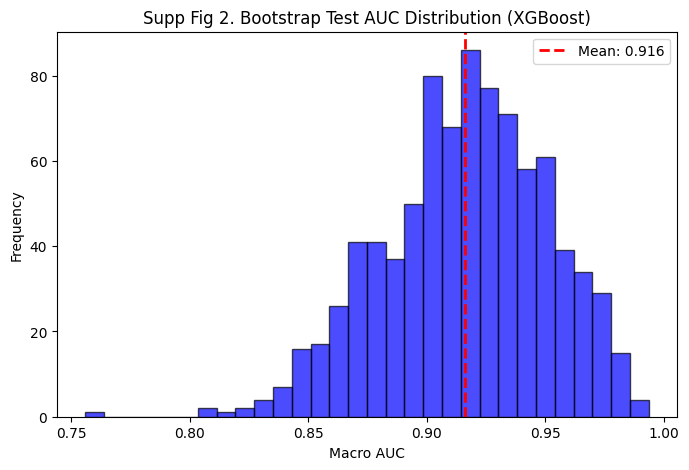

Saved: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\results\figures\supp_fig2_bootstrap_auc_dist.png


In [5]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_score, recall_score

# Table 1: Model Comparison
results = []
for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])

    macro_auc = roc_auc_score(y_test, y_proba, average='macro', multi_class='ovr')
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    acc = accuracy_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    results.append({
        'Model': name,
        'Test_AUC_Macro': macro_auc,
        'Test_F1_Macro': macro_f1,
        'Test_Accuracy': acc,
        'Test_MCC': mcc
    })

table1_df = pd.DataFrame(results).sort_values("Test_F1_Macro", ascending=False)
table1_df.to_csv(RESULTS_TAB / "table1_model_comparison.csv", index=False)
print("Table 1: Model Comparison on Test Set")
print(table1_df)

# Select best model
best_model_name = table1_df.iloc[0]['Model']
best_model = tuned_models[best_model_name]

# Save copy as best_model for downstream NB06
joblib.dump(best_model, RESULTS_MOD / "best_model.pkl")

# Bootstrap CIs for all models
print("\nComputing 95% Bootstrap CIs (n=1000)...")
n_boot = 1000
boot_results = []
rng = np.random.RandomState(RANDOM_SEED)

# For Supp Fig 2
best_model_boot_aucs = []

for name, model in tuned_models.items():
    y_proba = model.predict_proba(X_test)
    y_pred = model.predict(X_test)
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
    
    boot_macro_auc = []
    
    for _ in range(n_boot):
        idx = rng.choice(len(y_test), size=len(y_test), replace=True)
        y_t = y_test.values[idx]
        y_pr = y_proba[idx]
        y_tb = y_test_bin[idx]
        
        if len(np.unique(y_t)) < 4:
            continue
            
        auc_val = roc_auc_score(y_t, y_pr, average='macro', multi_class='ovr')
        boot_macro_auc.append(auc_val)
        
    lo_auc, hi_auc = np.percentile(boot_macro_auc, [2.5, 97.5])
    boot_results.append({
        'Model': name,
        'Macro_AUC_mean': np.mean(boot_macro_auc),
        'Macro_AUC_CI_lo': lo_auc,
        'Macro_AUC_CI_hi': hi_auc
    })
    
    if name == best_model_name:
        best_model_boot_aucs = boot_macro_auc

boot_df = pd.DataFrame(boot_results)
boot_df.to_csv(RESULTS_TAB / "bootstrap_ci_results.csv", index=False)
print("Saved Bootstrap CIs")

# Supp Fig 2: Bootstrap AUC dist
plt.figure(figsize=(8, 5))
plt.hist(best_model_boot_aucs, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(np.mean(best_model_boot_aucs), color='red', linestyle='dashed', linewidth=2, label=f"Mean: {np.mean(best_model_boot_aucs):.3f}")
plt.title(f"Supp Fig 2. Bootstrap Test AUC Distribution ({best_model_name})")
plt.xlabel("Macro AUC")
plt.ylabel("Frequency")
plt.legend()
plt.savefig(RESULTS_FIG / "supp_fig2_bootstrap_auc_dist.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS_FIG / 'supp_fig2_bootstrap_auc_dist.png'}")

## 6. Confusion Matrix & ROC Visualization

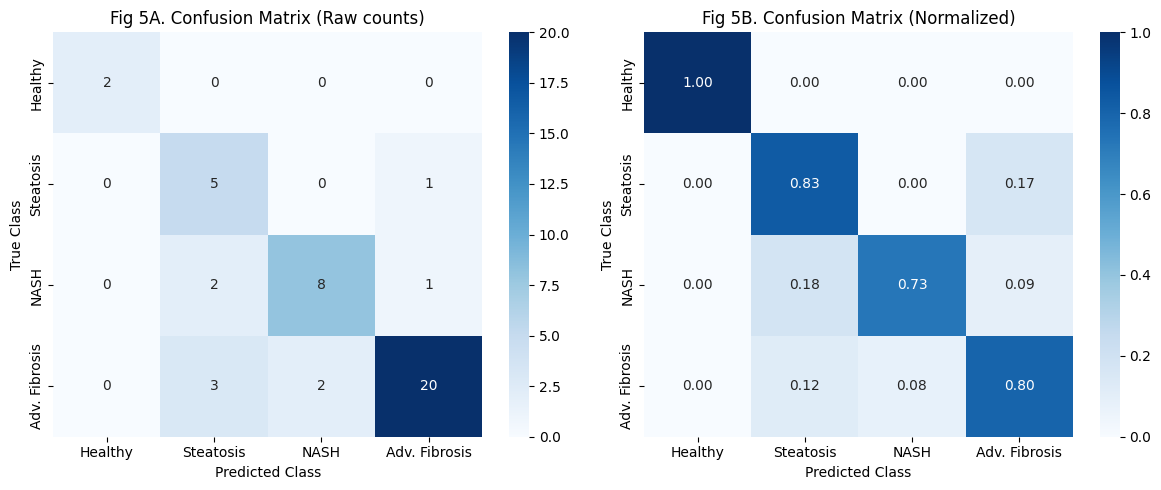

Saved: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\results\figures\fig5_confusion_matrix_both.png


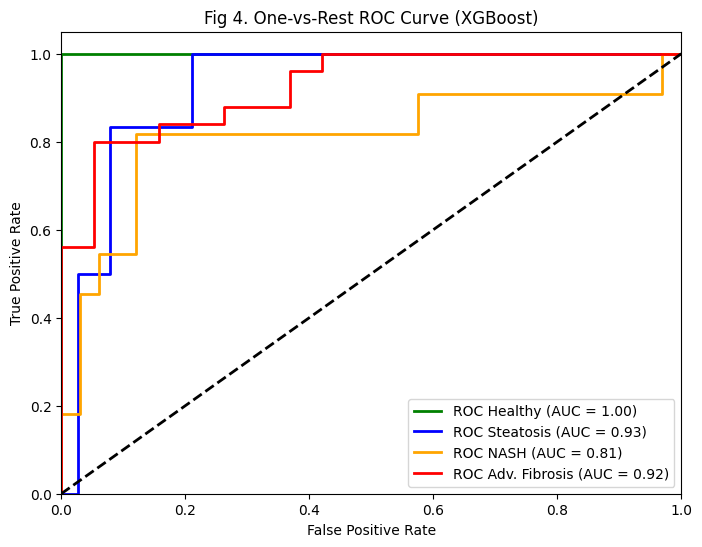

Saved: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\results\figures\fig4_roc_curve_ovr.png


In [7]:
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)

# Fig 5: Confusion Matrix (Raw & Normalized side-by-side)
cm_raw = confusion_matrix(y_test, y_test_pred)
cm_norm = confusion_matrix(y_test, y_test_pred, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title(f"Fig 5A. Confusion Matrix (Raw counts)")
axes[0].set_ylabel('True Class')
axes[0].set_xlabel('Predicted Class')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title(f"Fig 5B. Confusion Matrix (Normalized)")
axes[1].set_ylabel('True Class')
axes[1].set_xlabel('Predicted Class')

plt.tight_layout()
plt.savefig(RESULTS_FIG / "fig5_confusion_matrix_both.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS_FIG / 'fig5_confusion_matrix_both.png'}")

# Fig 4: Multi-class OvR ROC Plot
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])

plt.figure(figsize=(8, 6))
colors = ['green', 'blue', 'orange', 'red']

for i, color in zip(range(4), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'ROC {CLASS_NAMES[i]} (AUC = {roc_auc:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Fig 4. One-vs-Rest ROC Curve ({best_model_name})')
plt.legend(loc="lower right")
plt.savefig(RESULTS_FIG / "fig4_roc_curve_ovr.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS_FIG / 'fig4_roc_curve_ovr.png'}")